In [1]:
import pandas as pd
df = pd.read_csv('satelliteori.csv')

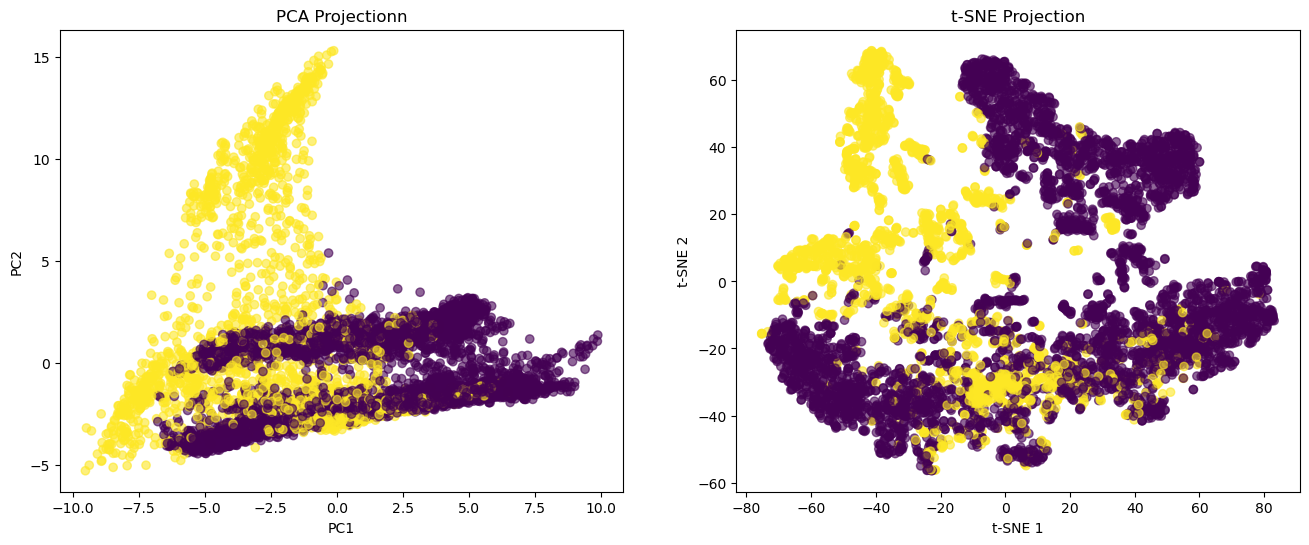

In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('label', axis=1)
X_scaled = StandardScaler().fit_transform(X)

# PCA (Linear Projection)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE (Non-linear Mapping)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA and t-SNE
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df['label'], cmap='viridis', alpha=0.6)
ax1.set_title(f'PCA Projectionn')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['label'], cmap='viridis', alpha=0.6)
ax2.set_title('t-SNE Projection')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

plt.show()